<h1>MOVIE RATING PREDICTION 
WITH PYTHON</h1>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df_movie = pd.read_csv(r"C:\Users\Acer\Documents\Encryptix\Movie_Rating\IMDb Movies India.csv", encoding='latin1')
df_cleaned = df_movie.dropna(subset=['Rating'])
df_cleaned = df_cleaned[['Genre', 'Year', 'Duration', 'Votes', 'Rating','Director']]
df_cleaned.fillna('Unknown', inplace=True)
df_cleaned['Genre'] = df_cleaned['Genre'].apply(lambda x: x.split(',')[0].strip())
df_cleaned.head()


,Genre,Year,Duration,Votes,Rating,Director
1,Drama,(2019),109 min,8,7.0,Gaurav Bakshi
3,Comedy,(2019),110 min,35,4.4,Ovais Khan
5,Comedy,(1997),147 min,827,4.7,Rahul Rawail
6,Drama,(2005),142 min,"1,086",7.4,Shoojit Sircar
8,Horror,(2012),82 min,326,5.6,Allyson Patel


In [9]:
df_cleaned.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


**Rating Distribution**

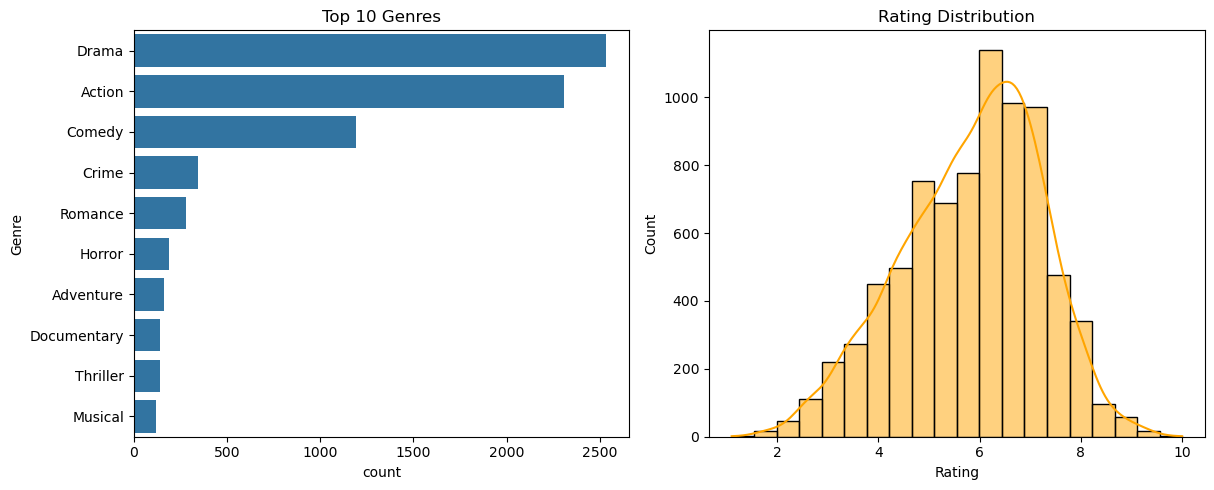

In [10]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=df_cleaned, y='Genre', order=df_cleaned['Genre'].value_counts().index[:10])
plt.title('Top 10 Genres')

plt.subplot(1, 3, 2)
sns.histplot(df_cleaned['Rating'], bins=20, kde=True, color='orange')
plt.title('Rating Distribution')

plt.tight_layout()
plt.show()

To get more accurate model we are considering Top 5 Genres and replace all others with "Other" 

In [11]:
top_genres = df_cleaned['Genre'].value_counts().nlargest(5).index
df_cleaned['Genre'] = df_cleaned['Genre'].apply(lambda x: x if x in top_genres else 'Other')


In [13]:
features = df_cleaned[['Genre', 'Votes', 'Duration', 'Year']]
target = df_cleaned['Rating']

**convert categorical data into numerical format**

In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(features)

<h1>Model Training</h1>

In [18]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, target, test_size=0.2, random_state=42)

In [30]:
model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, random_state=42)

In [31]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import r2_score, mean_squared_error

train_score = r2_score(y_train, y_train_pred)
test_score = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

**Accuracy Scores**

In [33]:
print(f"Training Accuracy: {train_score:.3f}")
print(f"Testing Accuracy : {test_score:.3f}")
print(f"Test RMSE: {rmse_test:.3f}")

Training Accuracy: 0.256
Testing Accuracy : 0.117
Test RMSE: 1.281


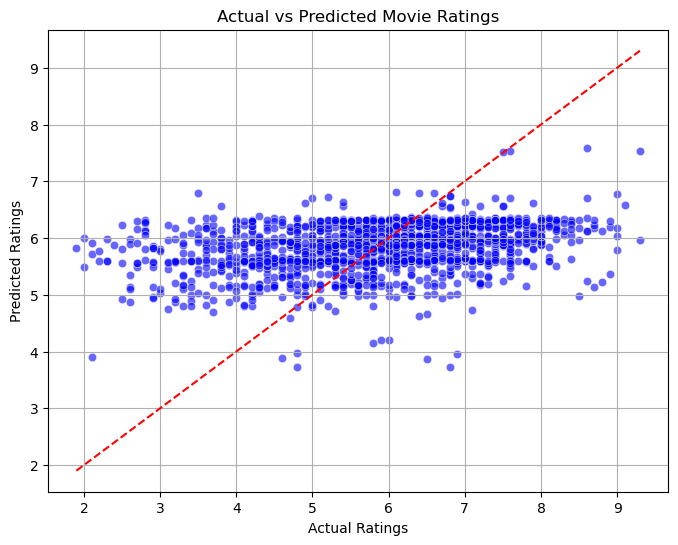

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6, color='blue')  # use correct variable
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")
plt.grid(True)
plt.show()

<h1>Model Testing</h1>

In [36]:
# ✅ Sample test input (with Duration, no Actor 3)
sample_movie = pd.DataFrame([{
    'Genre': 'Action',
    'Director': 'Rohit Shetty',
    'Actor 1': 'Ajay Devgn',
    'Actor 2': 'Kareena Kapoor',
    'Duration': 150  # example in minutes
}])

# Ensure column order matches
sample_movie = sample_movie[features.columns]

# Encode and predict
sample_encoded = encoder.transform(sample_movie)
predicted_rating = model.predict(sample_encoded)

print(f"🎬 Predicted Rating: {predicted_rating[0]:.2f}")


KeyError: "['Votes', 'Year'] not in index"